In [1]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import smarts_cerebellum.globals as gl

reds = 'tomato'
blues = 'steelblue'

In [2]:
# currently avaialble: 'WM_mod', 'T1'
segment = 'WM'

# obs means
patients_actual = pd.read_csv(os.path.join(gl.baseDir, f'MNISymC_{segment}', 'means', f'summary_patients_MNISymC_CST_{segment}_mod_mean.tsv'), sep = '\t')
controls_actual = pd.read_csv(os.path.join(gl.baseDir, f'MNISymC_{segment}', 'means', f'summary_controls_MNISymC_CST_{segment}_mod_mean.tsv'), sep = '\t')

# pred means
patients_lme = pd.read_csv(os.path.join(gl.baseDir, 'lme', f'patients_MNISymC_{segment}_mod_CST_lme.tsv'), sep = '\t')
controls_lme = pd.read_csv(os.path.join(gl.baseDir, 'lme', f'controls_MNISymC_{segment}_mod_CST_lme.tsv'), sep = '\t')

# confidence intervals (95th percentile)
patients_lme['e_lower'] = patients_lme['beta'] - patients_lme['ci_lower']
patients_lme['e_upper'] = patients_lme['ci_upper'] - patients_lme['beta']

# get hemisphere
patients_lme['hemisphere'] = patients_lme.regionname.str[0]
controls_lme['hemisphere'] = controls_lme.regionname.str[0]
patients_actual['hemisphere'] = patients_actual.regionname.str[0]
controls_actual['hemisphere'] = controls_actual.regionname.str[0]

left_patients_lme = patients_lme[patients_lme.hemisphere == 'l'].sort_values('Week')
left_patients_actual = patients_actual[patients_actual.hemisphere == 'l'].sort_values('Week')
left_controls_lme = controls_lme[controls_lme.hemisphere == 'l'].sort_values('Week')
left_controls_actual = controls_actual[controls_actual.hemisphere == 'l'].sort_values('Week')

right_patients_lme = patients_lme[patients_lme.hemisphere == 'r'].sort_values('Week')
right_patients_actual = patients_actual[patients_actual.hemisphere == 'r'].sort_values('Week')
right_controls_lme = controls_lme[controls_lme.hemisphere == 'r'].sort_values('Week')
right_controls_actual = controls_actual[controls_actual.hemisphere == 'r'].sort_values('Week')

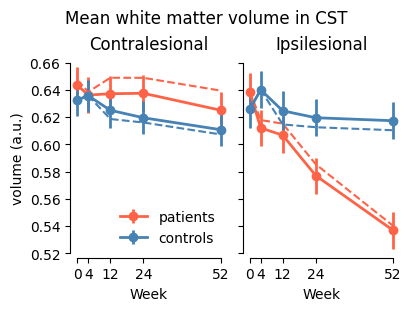

In [3]:
fig, axs = plt.subplots(1,2, figsize=(4,3), sharey = True, constrained_layout=True)

for i, H in enumerate(gl.Hem):

    ax = axs[i]

    patients_lme_h    = patients_lme[patients_lme.hemisphere == H].sort_values('Week')
    patients_actual_h = patients_actual[patients_actual.hemisphere == H].sort_values('Week')
    controls_lme_h    = controls_lme[controls_lme.hemisphere == H].sort_values('Week')
    controls_actual_h = controls_actual[controls_actual.hemisphere == H].sort_values('Week')

    ax.errorbar(x=patients_lme_h['Week'], y=patients_lme_h['beta'], yerr = patients_lme_h['se'], fmt = '-o', color = reds, linewidth = 2, label = 'patients')
    ax.plot(patients_actual_h['Week'], patients_actual_h['mean'], color = reds, linestyle = '--')

    ax.errorbar(x=controls_lme_h['Week'], y=controls_lme_h['beta'], yerr = controls_lme_h['se'], fmt = '-o', color = blues, linewidth = 2, label = 'controls')
    ax.plot(controls_actual_h['Week'], controls_actual_h['mean'], color = blues, linestyle = '--',)

    ax.set_title("Contralesional")
    ax.legend(loc = 'lower right', frameon = False) if i == 0 else None

for i in range(2):
    axs[i].set_xticks(gl.weeks)
    axs[i].set_xlabel("Week")
    axs[i].set_title(gl.side[i])

axs[0].set_ylabel('volume (a.u.)')

fig.suptitle('Mean white matter volume in CST')
sns.despine(trim = True)

fig.savefig('figure/lme_CST.pdf')

plt.show()